# 🤖 Using ChatGPT on Shap for Explinability

chat GPT in shap

## 🛠️ Setup Environment
First, we'll set up our environment and import necessary libraries for SHAP analysis and visualization.


In [18]:
import pickle
import shap
import pandas as pd
from openai import OpenAI
import textwrap
import json
import numpy as np

## 📥 Load Data and Model

In [8]:
lgbm_model = pickle.load(open('../../models/optuna_model.pkl', 'rb'))
oot = pd.read_parquet('../../data/oot_data.parquet')
oot_y = oot['is_fraud']
oot_X = oot.drop(columns=['is_fraud'] ) #+ metadata_columns)
oot_X = oot_X[lgbm_model.feature_name_]

## 📈 Calculate SHAP values

In [9]:
# print the JS visualization code to the notebook
shap.initjs()
explainer = shap.TreeExplainer(lgbm_model,feature_perturbation="tree_path_dependent")
shap_values = explainer(oot_X)

## 🤖 ChatGPT Integration - Using OpenAI API
* 🔄 Initialize the client
* 💬 Initialize completion explainer

In [ ]:
# Insert personal OpenAI API Key
openai_api_key = json.load(open('../../notebooks/explenaibility/secret.json', 'r'))['openai_api_key']
OPENAI_API_KEY = openai_api_key

In [12]:
client = OpenAI(
    organization="org-u7OSeiihFrxVgsOUT1Lh5MqD",
    project="proj_UAUstOfERtcBh4lXsDLilbsK",
    api_key=OPENAI_API_KEY
) 

In [13]:
completion = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {
            "role": "user",
            "content": "Write a haiku about recursion in programming."
        }
    ]
)

print(completion.choices[0].message)

ChatCompletionMessage(content='A call to itself,  \nEchoes in the tangled code,  \nInfinity’s dance.', refusal=None, role='assistant', audio=None, function_call=None, tool_calls=None, annotations=[])


## 📱 Create a callable for model explaination: the ExplainDecision Class

The `ExplainDecision` class provides a comprehensive solution for explaining model predictions by combining SHAP analysis with ChatGPT-generated insights. Here's how it works:

1. 📱 **Initialization**
   - Takes SHAP values, transaction IDs, predictions, and threshold
   - Sets up the foundation for model explanation

2. �� **Data Preparation**
   - Validates transaction ID existence
   - Creates feature importance dataframe
   - Ranks features by absolute SHAP values

3. 📈 **Visualization**
   - Generates SHAP waterfall plots
   - Shows feature contribution hierarchy
   - Visualizes prediction impact

4. 🤖 **ChatGPT Integration**
   - Formats SHAP insights for natural language
   - Generates human-readable explanations
   - Includes numerical evidence

5. 📝 **Output**
   - Returns both visual and textual explanations
   - Provides clear reasoning for model decisions
   - Highlights key contributing factors

In [39]:
class ExplainDecision:
    """
    A class for explaining model predictions using SHAP values and ChatGPT-generated insights.
    
    This class combines SHAP (SHapley Additive exPlanations) analysis with ChatGPT to provide
    both visual and textual explanations of model predictions. It's particularly useful for
    fraud detection models where interpretability is crucial.
    
    Attributes:
        _shap_values (Explanation): SHAP values object containing feature importance information
        _transaction_id_list (array): List of transaction IDs in the dataset
        _pred_vect (array): Vector of model predictions
        _threshold_prediction (float): Threshold value for binary classification
    
    Example:
        >>> ed = ExplainDecision(shap_values=shap_values,
        ...                      transaction_id_list=oot_X.index,
        ...                      prediction_vector=model.predict(oot_X),
        ...                      threshold=0.5)
        >>> explanation = ed.explain_decision(transaction_id=123)
    """
     
    def __init__(self, shap_values, transaction_id_list, prediction_vector, threshold):
        """
        Initialize the ExplainDecision class.
        
        Args:
            shap_values (Explanation): SHAP values object from the model
            transaction_id_list (array): List of transaction IDs
            prediction_vector (array): Model predictions
            threshold (float): Classification threshold
        """
        self._shap_values = shap_values
        self._transaction_id_list = transaction_id_list
        self._pred_vect = prediction_vector
        self._threshold_prediction = threshold

    def _prepare_df(self, transaction_id: int) -> tuple[int, pd.DataFrame]:
        """
        Prepare a dataframe with feature importance information for a specific transaction.
        
        Args:
            transaction_id: The ID of the transaction to analyze
            
        Returns:
            tuple: (transaction_index, DataFrame) containing:
                - transaction_index: Index of the transaction in the dataset
                - DataFrame: Sorted features by absolute SHAP values
                
        Raises:
            ValueError: If transaction_id is not found in the dataset
        """
        try:
            transaction_index = np.where(self._transaction_id_list == transaction_id)[0][0]
        except:
            raise ValueError("Transaction ID not found in the dataset")

        df = pd.DataFrame({'Values': self._shap_values.values[transaction_index,:], 'Data': self._shap_values.data[transaction_index], 'feature_names': shap_values.feature_names})
        df['Rank_Abs_Values'] = df['Values'].abs().rank(ascending=False)
        df = df.sort_values('Rank_Abs_Values').reset_index(drop = True)

        return transaction_index, df
    
    # Create function to plot Shap Waterfall Chart
    @staticmethod
    def plot_waterfall(shap_values_transaction):
        """
        Create a SHAP waterfall plot for a specific transaction.
        
        Args:
            shap_values_transaction: SHAP values for a specific transaction
            
        Returns:
            Figure: SHAP waterfall plot
        """
        plot =  shap.plots.waterfall(shap_values_transaction)

        return plot

    def explain_decision(self, transaction_id):
        """
        Generate a comprehensive explanation for a model's prediction on a specific transaction.
        
        This method combines SHAP analysis with ChatGPT to provide both visual and textual
        explanations of why the model made a particular prediction.
        
        Args:
            transaction_id: The ID of the transaction to explain
            
        Returns:
            Figure: SHAP waterfall plot showing feature contributions
            
        The method will also print a ChatGPT-generated explanation of the prediction.
        """
        transaction_index, df = self._prepare_df(transaction_id)

        # Plot the Waterfall chart
        plot =  shap.plots.waterfall(shap_values[transaction_index,:])

        if self._pred_vect[transaction_index] >= self._threshold_prediction:
            prediction_string = "This is a fraudulent transaction."
        elif self._pred_vect[transaction_index] < self._threshold_prediction:
            prediction_string = "This is not a fraudulent transaction."

        df_string = df[0:5].to_string(index=False)

        text_input = f"""
                        {prediction_string} \n
                        Below is the dataset of the 5 largest contributing factors to this outcome. \n
                        Values field is the amount it contributes to the outcome, the more positive the more likely it is fraud, the more negative the less likely it is not fraud. \n
                        Data is the normalised data set.\n\n

                        Summarise this table into a short text, with no bullet points, explaining why this transaction was classed as this way based on the below information. 
                        Use the data to explain the decision. Add numerical values to the explanation.\n\n

                        {df_string}
                    """
        
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
                    {
                    "role": "system",
                    "content": "You are a data analyst making observations for executives"  # Define the system context
                    },
                    {
                    "role": "user",
                    "content": text_input    # Input the main prompt
                    },
                    {
                    "role": "user",
                    "content": """Key points to structure the answer.\n                                        
                                    Answer in a short paragraph without bullet points.\n
                                    Refer to "The Graph" which will be displayed with your response. \n
                                    When values are positive, this contirbutes to fraud..\n
                                    When values are negative, this contirbutes to genuine transactions..\n  
                                    Add numerical values to the explanation.\n
                                    """        }  # Define the user context
                        ],
            temperature=1,
            max_tokens=256,
            top_p=1,
            frequency_penalty=0.2,
            presence_penalty=0.2
            )

        # Save the response
        gpt_response = response.choices[0].message.content

        # Deifne wrapper to format response 
        wrapper = textwrap.TextWrapper(width=150) 
        
        # Apply wrapper to response
        word_list = wrapper.wrap(text=gpt_response) 

        # Print each line. 
        for element in word_list: 
            print(element) 

        return plot


## 📈 Results Analysis
Explain single predictions with shap and text
* 📊 Compare predictions
* 🔍 Analyze feature impact
* 🎯 Evaluate model behavior

In [40]:
ed = ExplainDecision(shap_values = shap_values, 
                     transaction_id_list= oot_X.index, 
                     prediction_vector = lgbm_model.predict(oot_X),
                     threshold = 0.5)

[LightGBM] [Warning] min_data_in_leaf is set=99, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=99


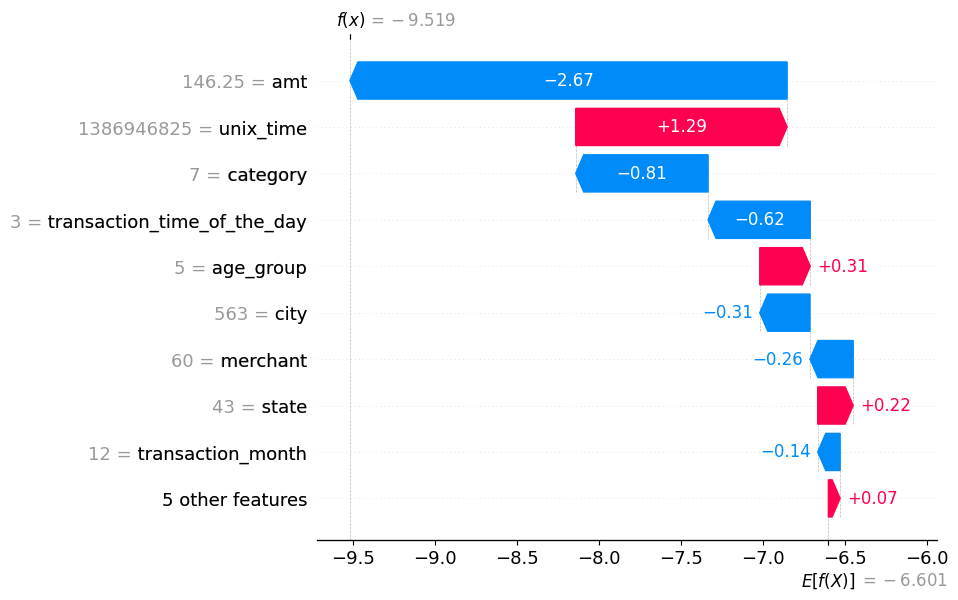

Based on the data provided, the transaction in question was classified as not fraudulent due to several key factors. The amount involved in the
transaction had a significant negative impact (-2.665880) on the likelihood of fraud, indicating it was lower compared to fraudulent transactions.
Additionally, the category of the transaction and the time of the day when it occurred both had negative influences (-0.807104 and -0.623048
respectively) on the probability of fraud, suggesting they aligned more with genuine transactions. In contrast, the unix time and age group associated
with the transaction had positive effects (1.289056 and 0.307831 respectively) that were less indicative of fraud. Overall, a combination of these
factors suggests that the transaction was deemed non-fraudulent based on these specific data points. Please refer to the graph for a visual
representation of these findings.


In [41]:
ed.explain_decision(oot_X.index[np.random.randint(0, len(oot_X))])

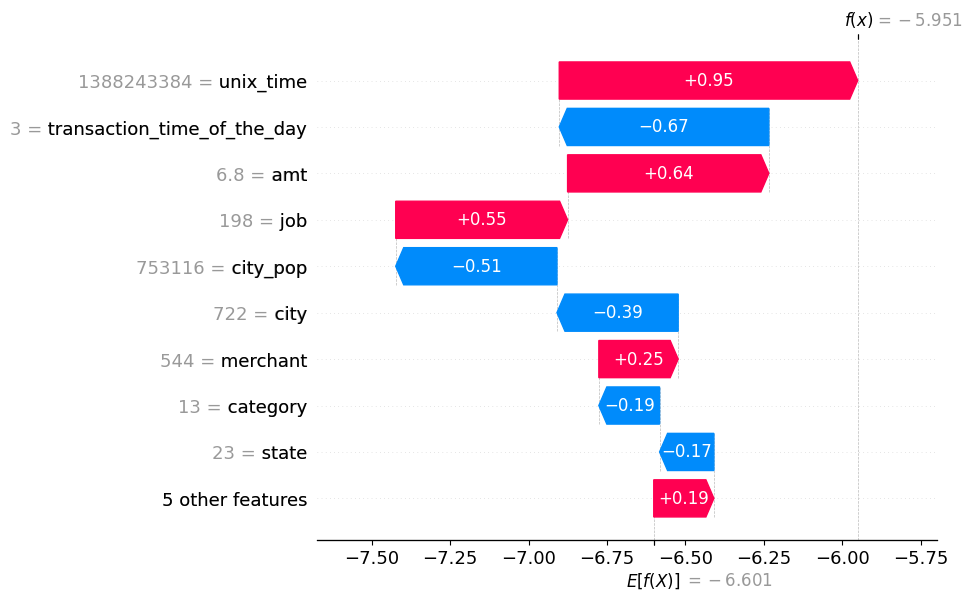

Based on the data provided, the transaction was classified as not fraudulent primarily due to the significant negative contribution from the
'transaction_time_of_the_day' feature with a value of -0.668. This was followed by the 'city_pop' feature, which also had a negative impact on the
classification with a value of -0.514. Conversely, the 'unix_time' feature had the highest positive impact on indicating fraud with a value of 0.952,
while 'amt' and 'job' also contributed positively to the likelihood of fraud with values of 0.642 and 0.548, respectively. This decision was likely
influenced by the combination of these factors as shown in "The Graph."


In [42]:
ed.explain_decision(oot_X.index[np.random.randint(0, len(oot_X))])

[LightGBM] [Warning] min_data_in_leaf is set=99, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=99


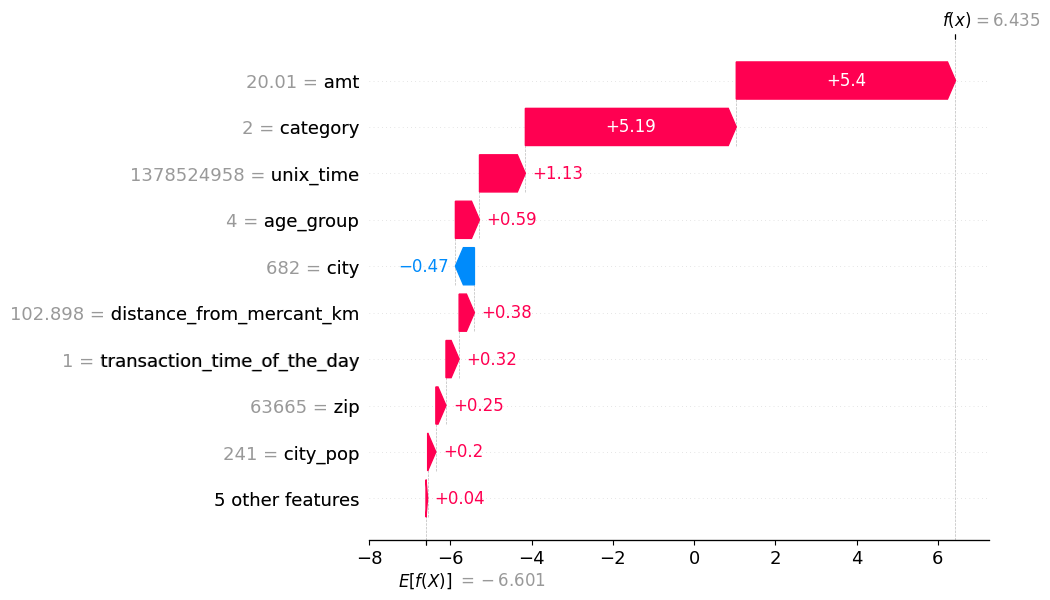

Based on the data provided, the transaction was classified as fraudulent due to several factors. The amount (amt) had the highest positive impact
value of 5.3975, indicating a significant contribution to fraud. Additionally, the category of transaction (category) and the timestamp of the
transaction (unix_time) also showed positive impact values of 5.1926 and 1.1294 respectively, further suggesting fraudulent activity. Conversely,
features like age group (age_group) and city (city) had negative impact values of 0.5930 and -0.4684, implying that transactions with lower age groups
and originating from certain cities are less likely to be fraudulent. These factors collectively influenced the decision regarding the classification
of this transaction as fraudulent, with a cumulative impact value favoring fraud.


In [43]:
prediction_vector = lgbm_model.predict(oot_X)
ed.explain_decision(oot_X.index[np.random.choice(np.where(prediction_vector==1)[0])])